# Notebook 02 — Feature Engineering

**Goal:** Compute all behavioural features from the enriched scrobble data and produce a user-level feature matrix for clustering.

**Inputs** (from `data/processed/`):
- `scrobbles_updated.parquet`
- `profiles.parquet`
- `artist_genres.parquet`
- `audio_features.parquet`

**Outputs:**
- `data/processed/user_features.parquet` — one row per user, all features

**Features computed:**

| Group | Features |
|---|---|
| Artist diversity | unique_artists, artist_entropy, artist_concentration_20 |
| Genre diversity | unique_genres, genre_entropy, genre_concentration_5, avg_genre_tags_per_play |
| Engagement | total_scrobbles, unique_tracks, track_replay_rate, avg_tracks_per_session, session_count |
| Discovery | discovery_velocity_30d/90d, novelty_ratio, top_artist_play_share |
| Temporal | temporal_hour/dow/month_entropy, morning/evening/weekend_ratio, temporal_stability_pc1..5 |
| Audio profile | mean danceability, energy, valence, tempo, acousticness, instrumentalness |

In [1]:
import sys
import logging
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(name)s: %(message)s')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load all enriched data
scrobbles    = pd.read_parquet('../data/processed/scrobbles_updated.parquet')
profiles     = pd.read_parquet('../data/processed/profiles.parquet')
artist_genres = pd.read_parquet('../data/processed/artist_genres.parquet')
audio_features = pd.read_parquet('../data/processed/audio_features.parquet')

print(f'Scrobbles: {len(scrobbles):,} rows, {scrobbles["userid"].nunique()} users')
print(f'Artist genres: {len(artist_genres):,} artists, {artist_genres["spotify_artist_id"].notna().sum():,} matched')
print(f'Audio features: {len(audio_features):,} tracks')

Scrobbles: 47,420 rows, 50 users
Artist genres: 120 artists, 120 matched
Audio features: 944 tracks


## 1. Artist Diversity Features

In [3]:
from src.features.diversity import compute_artist_diversity

artist_div = compute_artist_diversity(scrobbles, top_n=20)
print(f'Artist diversity features: {artist_div.shape}')
artist_div.describe()

Artist diversity features: (50, 3)


,unique_artists,artist_entropy,artist_concentration_20
count,50.00000,50.000000,50.000000
mean,103.56000,6.163635,0.490224
std,7.18888,0.104681,0.032811
min,84.00000,5.859569,0.408117
25%,99.00000,6.108404,0.469452
50%,105.50000,6.172013,0.482850
75%,108.00000,6.243739,0.505487
max,117.00000,6.319146,0.586645


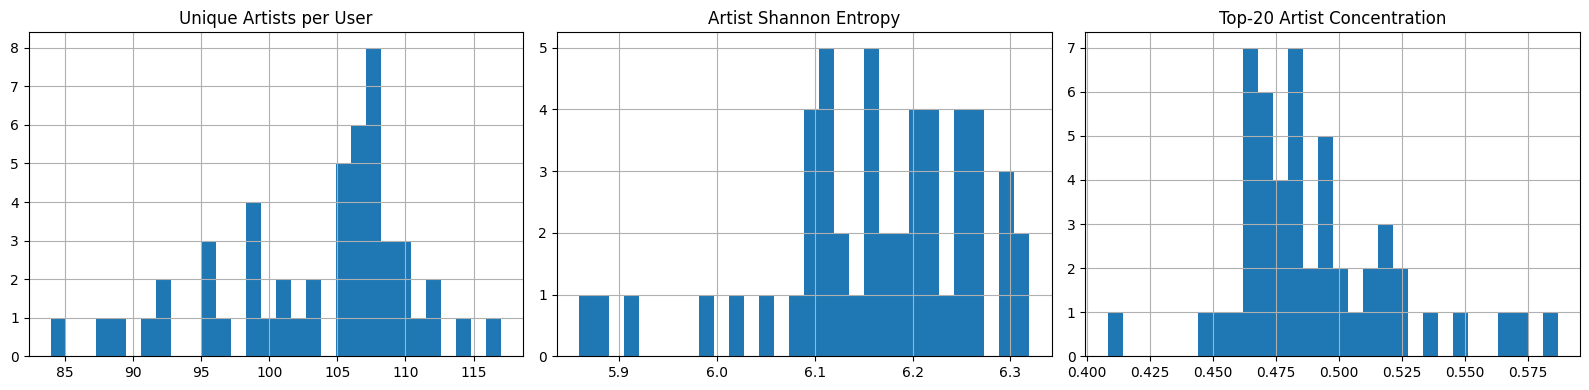

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
artist_div['unique_artists'].hist(ax=axes[0], bins=30)
axes[0].set_title('Unique Artists per User')

artist_div['artist_entropy'].hist(ax=axes[1], bins=30)
axes[1].set_title('Artist Shannon Entropy')

artist_div['artist_concentration_20'].hist(ax=axes[2], bins=30)
axes[2].set_title('Top-20 Artist Concentration')

plt.tight_layout()
plt.show()

## 2. Genre Diversity Features

In [5]:
from src.features.diversity import compute_genre_diversity

genre_div = compute_genre_diversity(scrobbles, artist_genres, top_n=5)
print(f'Genre diversity features: {genre_div.shape}')
genre_div.describe()

Genre diversity features: (50, 4)


,unique_genres,genre_entropy,genre_concentration_5,avg_genre_tags_per_play
count,50.0,50.000000,50.000000,50.000000
mean,30.0,4.759313,0.287079,2.980243
std,0.0,0.034052,0.019916,0.067297
min,30.0,4.673860,0.239230,2.818182
25%,30.0,4.740150,0.275004,2.931983
50%,30.0,4.758295,0.282808,2.985639
75%,30.0,4.782056,0.297396,3.035971
max,30.0,4.831345,0.337772,3.093596


## 3. Temporal Features

Includes PCA-compressed hourly listening profiles to capture **listening pattern stability** while avoiding multicollinearity across 24 hour-of-day columns.

In [6]:
from src.features.temporal import compute_temporal_features

temporal = compute_temporal_features(scrobbles, pca_components=5)
print(f'Temporal features: {temporal.shape}')
temporal.describe()

Temporal features: (50, 13)


,temporal_hour_entropy,temporal_dow_entropy,temporal_month_entropy,morning_ratio,evening_ratio,weekend_ratio,listening_days,avg_daily_plays,temporal_stability_pc1,temporal_stability_pc2,temporal_stability_pc3,temporal_stability_pc4,temporal_stability_pc5
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,50.000000
mean,4.561670,2.802500,3.573286,0.248162,0.251922,0.284657,715.880000,0.520531,-1.509903e-16,5.329071e-17,-8.437695e-17,-8.881784e-18,0.000000
std,0.015608,0.003387,0.008311,0.013425,0.016771,0.015363,229.322662,0.204476,1.718688e+00,1.600374e+00,1.487131e+00,1.466779e+00,1.397086
min,4.502623,2.790933,3.553189,0.220326,0.217391,0.251928,234.000000,0.140969,-3.677039e+00,-3.016268e+00,-2.931341e+00,-3.539687e+00,-5.055876
25%,4.556221,2.800866,3.571315,0.241057,0.239939,0.272765,525.750000,0.341405,-9.881349e-01,-9.432774e-01,-5.307987e-01,-7.292469e-01,-0.658256
50%,4.568659,2.803573,3.576942,0.245441,0.250635,0.287167,746.000000,0.523153,-2.116982e-02,-1.687297e-01,-1.042136e-01,-2.474277e-02,0.120284
75%,4.572309,2.804952,3.578590,0.258454,0.264377,0.294980,922.500000,0.705349,9.738086e-01,7.796646e-01,4.676190e-01,9.769258e-01,0.677677
max,4.577893,2.806449,3.582302,0.275665,0.292969,0.318862,1016.000000,0.813151,4.877181e+00,6.118036e+00,6.828425e+00,4.153887e+00,2.840323


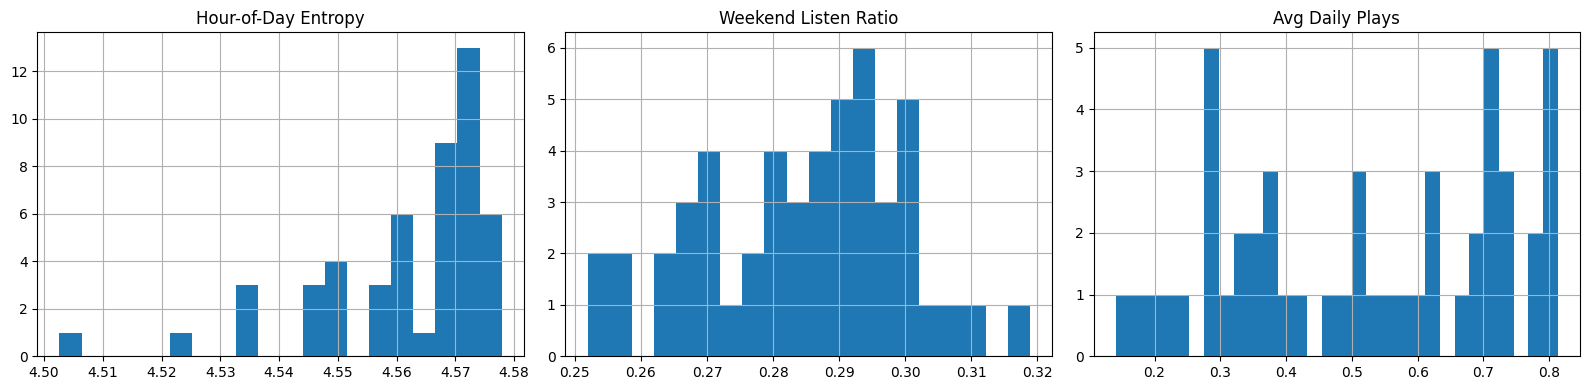

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
temporal['temporal_hour_entropy'].hist(ax=axes[0], bins=20)
axes[0].set_title('Hour-of-Day Entropy')

temporal['weekend_ratio'].hist(ax=axes[1], bins=20)
axes[1].set_title('Weekend Listen Ratio')

temporal['avg_daily_plays'].hist(ax=axes[2], bins=30)
axes[2].set_title('Avg Daily Plays')

plt.tight_layout()
plt.show()

## 4. Engagement & Discovery Features

In [8]:
from src.features.engagement import compute_engagement_features

engagement = compute_engagement_features(scrobbles, session_gap_minutes=30)
print(f'Engagement features: {engagement.shape}')
engagement.describe()

Engagement features: (50, 10)


,total_scrobbles,unique_tracks,track_replay_rate,avg_tracks_per_session,session_count,avg_session_length_min,discovery_velocity_30d,discovery_velocity_90d,novelty_ratio,top_artist_play_share
count,50.000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,948.400,453.860000,2.004679,1.010919,936.720000,0.164677,0.008000,0.006889,0.021450,0.049445
std,373.406,105.399533,0.401682,0.005512,365.906983,0.092364,0.015879,0.008948,0.037473,0.013685
min,256.000,199.000000,1.286432,1.000000,255.000000,0.000000,0.000000,0.000000,0.000000,0.029703
25%,620.000,371.250000,1.669121,1.007659,615.000000,0.102055,0.000000,0.000000,0.000000,0.040280
50%,954.500,486.000000,1.997898,1.011009,944.500000,0.164723,0.000000,0.000000,0.000000,0.047706
75%,1285.500,547.250000,2.351313,1.013829,1268.750000,0.209579,0.000000,0.011111,0.030303,0.053739
max,1484.000,580.000000,2.695255,1.024390,1467.000000,0.407568,0.066667,0.033333,0.176471,0.093750


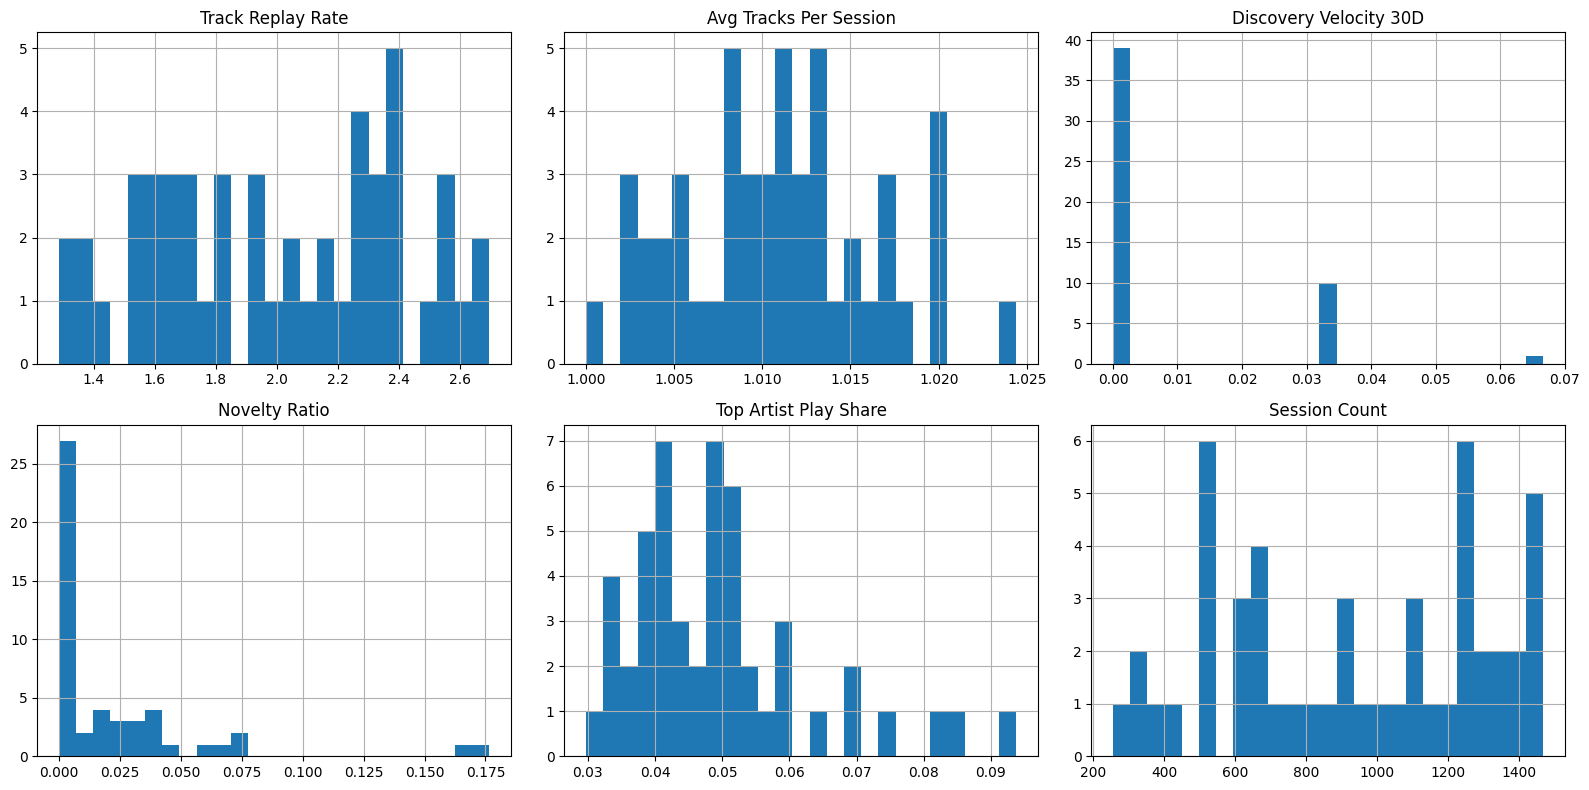

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(['track_replay_rate', 'avg_tracks_per_session',
                          'discovery_velocity_30d', 'novelty_ratio',
                          'top_artist_play_share', 'session_count']):
    engagement[col].hist(ax=axes[i], bins=25)
    axes[i].set_title(col.replace('_', ' ').title())

plt.tight_layout()
plt.show()

## 5. Audio Feature Profile

In [10]:
from src.features.engagement import compute_audio_feature_profile

audio_profile = compute_audio_feature_profile(scrobbles, audio_features)
print(f'Audio feature profile: {audio_profile.shape}')
audio_profile.head()

Audio feature profile: (50, 8)


,mean_danceability,mean_energy,mean_valence,mean_tempo,mean_acousticness,mean_instrumentalness,mean_liveness,mean_speechiness
userid,,,,,,,,
user_0000,0.512669,0.533598,0.495292,116.485267,0.479915,0.452507,0.280696,0.184070
user_0001,0.487344,0.517079,0.498715,119.668173,0.470400,0.446174,0.272179,0.189018
user_0002,0.507096,0.538152,0.492869,122.925366,0.473043,0.443921,0.270077,0.181387
user_0003,0.495879,0.531854,0.496933,118.545044,0.458518,0.451839,0.261795,0.189637
user_0004,0.507648,0.527037,0.484364,118.315082,0.476869,0.443717,0.271831,0.188005


## 6. Build Final Feature Matrix

In [11]:
from src.features.builder import build_feature_matrix

feature_matrix = build_feature_matrix(
    scrobbles=scrobbles,
    artist_genres=artist_genres,
    audio_features=audio_features,
    profiles=profiles,
    config_path='../configs/config.yaml',
    save_path='../data/processed/user_features.parquet',
)

print(f'Feature matrix: {feature_matrix.shape[0]} users × {feature_matrix.shape[1]} features')
feature_matrix.head()

2026-03-24 05:47:55,942 [INFO] src.features.builder: Computing artist diversity features...


2026-03-24 05:47:56,001 [INFO] src.features.builder: Computing genre diversity features...


2026-03-24 05:47:56,299 [INFO] src.features.builder: Computing temporal features...


2026-03-24 05:47:56,519 [INFO] src.features.builder: Computing engagement and discovery features...


2026-03-24 05:48:00,143 [INFO] src.features.builder: Computing audio feature profile...


2026-03-24 05:48:00,195 [INFO] src.features.builder: Feature matrix: 50 users × 41 features


2026-03-24 05:48:00,201 [INFO] src.features.builder: Feature matrix saved to ../data/processed/user_features.parquet


Feature matrix: 50 users × 41 features


,unique_artists,artist_entropy,artist_concentration_20,unique_genres,genre_entropy,genre_concentration_5,avg_genre_tags_per_play,temporal_hour_entropy,temporal_dow_entropy,temporal_month_entropy,...,mean_energy,mean_valence,mean_tempo,mean_acousticness,mean_instrumentalness,mean_liveness,mean_speechiness,gender,age,country
userid,,,,,,,,,,,,,,,,,,,,,
user_0000,108,6.227157,0.471947,30,4.731402,0.279778,2.991291,4.577893,2.803595,3.579081,...,0.533598,0.495292,116.485267,0.479915,0.452507,0.280696,0.184070,m,30.0,Netherlands
user_0001,103,6.125337,0.520990,30,4.739283,0.298130,3.059322,4.558841,2.798189,3.577807,...,0.517079,0.498715,119.668173,0.470400,0.446174,0.272179,0.189018,m,58.0,Australia
user_0002,96,6.153023,0.474453,30,4.763127,0.281599,3.053860,4.544566,2.805812,3.568421,...,0.538152,0.492869,122.925366,0.473043,0.443921,0.270077,0.181387,n,51.0,United States
user_0003,102,6.175143,0.492562,30,4.742750,0.293956,2.902711,4.549374,2.799858,3.576084,...,0.531854,0.496933,118.545044,0.458518,0.451839,0.261795,0.189637,n,49.0,Brazil
user_0004,99,5.983847,0.549401,30,4.799511,0.239230,2.914328,4.556194,2.796528,3.565804,...,0.527037,0.484364,118.315082,0.476869,0.443717,0.271831,0.188005,f,18.0,Brazil


## 7. Correlation Analysis & Multicollinearity Check

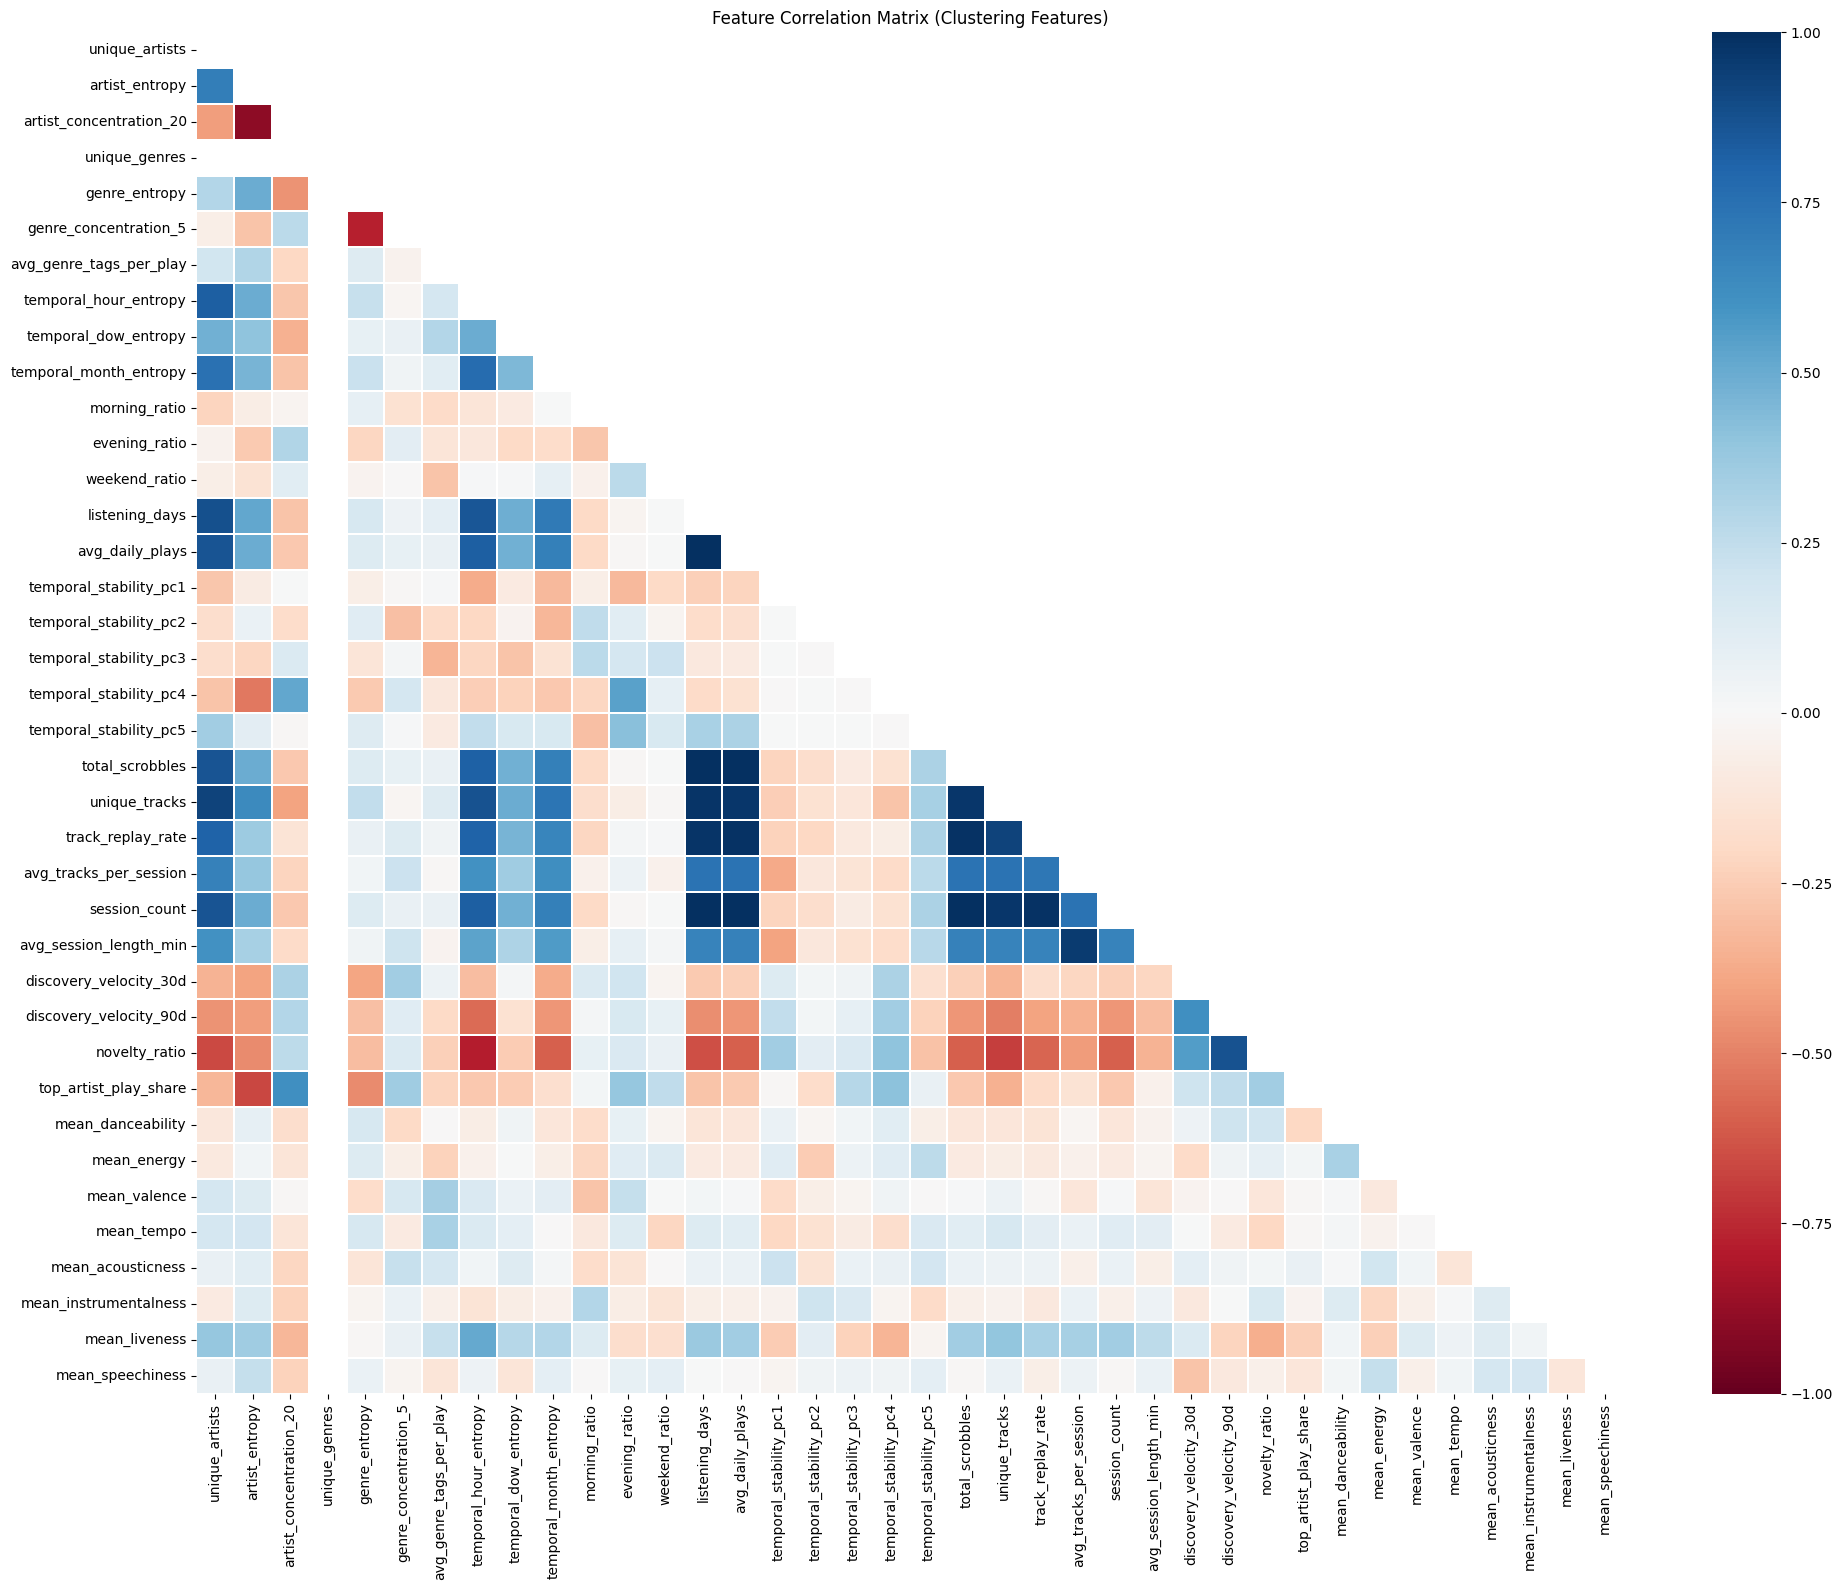

Highly correlated pairs (|r|>0.75): 34
                      feat_a                  feat_b  correlation
184          total_scrobbles         avg_daily_plays     0.999994
272            session_count         total_scrobbles     0.999940
266            session_count         avg_daily_plays     0.999934
265            session_count          listening_days     0.995875
90           avg_daily_plays          listening_days     0.995622
183          total_scrobbles          listening_days     0.995563
223        track_replay_rate         avg_daily_plays     0.985911
229        track_replay_rate         total_scrobbles     0.985848
274            session_count       track_replay_rate     0.985730
202            unique_tracks          listening_days     0.983022
222        track_replay_rate          listening_days     0.979585
273            session_count           unique_tracks     0.971372
203            unique_tracks         avg_daily_plays     0.970917
209            unique_tracks         

In [12]:
# Select numeric clustering features (exclude demographics)
clustering_features = feature_matrix.select_dtypes(include=[np.number]).drop(
    columns=['age'], errors='ignore'
)

corr = clustering_features.corr()

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu', center=0, vmin=-1, vmax=1,
    annot=False, fmt='.2f', linewidths=0.3,
)
plt.title('Feature Correlation Matrix (Clustering Features)')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Pairs with |r| > 0.75
high_corr = (
    corr.abs().where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack().reset_index()
    .rename(columns={0: 'correlation', 'level_0': 'feat_a', 'level_1': 'feat_b'})
    .query('correlation > 0.75')
    .sort_values('correlation', ascending=False)
)
print(f'Highly correlated pairs (|r|>0.75): {len(high_corr)}')
print(high_corr.to_string())

> Note: Remaining multicollinearity is handled at the clustering stage via PCA dimensionality reduction before fitting KMeans/HDBSCAN.

Proceed to **Notebook 03** for clustering.